In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## Data Acquisition

In [2]:
#Import libraries and download data
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Define portfolio tickers
port_tickers = ['VTI', # U.S. Equity 
                'VEU', # Proxy for International Equity (VXUS)
                'VWO', # Emerging Markets
                'BND', # Bonds
                'GLD', #Gold
                'BIL' # Proxy for Cash (SGOV)
               ]

#Download historical data
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
data = yf.download(port_tickers, start="2007-01-01", end= end_date, auto_adjust = True)

#Extract adjusted close prices
prices = data["Close"]

#Save to csv for reproducibility
prices.to_csv("prices_close.csv")

[*********************100%***********************]  6 of 6 completed


## Data Loading and Inspection

In [3]:
#Load data from csv
prices = pd.read_csv("prices_close.csv", index_col = 0, parse_dates = True)

#Basic Dataset Overview
from IPython.display import display

#Data shape
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [prices.shape[0], prices.shape[1]]
})
display(shape_df.style.hide(axis="index"))

#Check Missing Values
missing = prices.isna().sum().to_frame(name="Missing Values")
missing = missing.sort_values("Missing Values", ascending=False)
display(missing)


Metric,Value
Rows,4959
Columns,6


,Missing Values
BIL,101
BND,66
VEU,44
GLD,0
VTI,0
VWO,0


In [4]:
#Check inception of ETFs
prices.info()
for port_ticker in prices.columns:
    first_valid = prices[port_ticker].first_valid_index()
    print(f"{port_ticker}: {first_valid}")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4959 entries, 2007-01-03 to 2026-09-18
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BIL     4858 non-null   float64
 1   BND     4893 non-null   float64
 2   GLD     4959 non-null   float64
 3   VEU     4915 non-null   float64
 4   VTI     4959 non-null   float64
 5   VWO     4959 non-null   float64
dtypes: float64(6)
memory usage: 271.2 KB
BIL: 2007-05-30 00:00:00
BND: 2007-04-10 00:00:00
GLD: 2007-01-03 00:00:00
VEU: 2007-03-08 00:00:00
VTI: 2007-01-03 00:00:00
VWO: 2007-01-03 00:00:00


## Data Quality Assessment

During the initial data review, VXUS and SGOV were found to have insufficient trading histories for the full backtest period because both ETFs launched after the desired sample start date. Rather than shorten the entire analysis, VEU and BIL were selected as historical proxies for international equity and short-term Treasury exposure, respectively.

VEU provides broad international equity exposure similar to the intended VXUS allocation but has a longer trading history. BIL serves the same purpose for the cash allocation by providing short-term U.S. Treasury bill exposure before SGOV became available.

The proxy substitutions are used only to extend the historical analysis. VXUS and SGOV remain the intended implementation ETFs in the portfolio design.

After the proxy substitutions, several observations were still unavailable in early 2007 because VEU, BND, and BIL had not yet begun trading. These pre-inception observations are removed rather than estimated or interpolated, so the final sample begins on the first date when all six historical series are available.


In [5]:

# Remove rows containing missing values
prices = prices.dropna()

print(f"Final sample start: {prices.index.min().date()}")
print(f"Final sample end: {prices.index.max().date()}")
print(f"Observations: {len(prices):,}")

# Missing values after cleaning
missing_after = (
    prices.isna()
    .sum()
    .to_frame(name="Missing Values After Cleaning")
)

display(missing_after)

Final sample start: 2007-05-30
Final sample end: 2026-09-18
Observations: 4,858


,Missing Values After Cleaning
BIL,0
BND,0
GLD,0
VEU,0
VTI,0
VWO,0


Historical price data were initially downloaded beginning January 1, 2007. Because VEU, BND, and BIL were launched during the first half of 2007, a small number of missing observations were present prior to their inception dates. 

To preserve data integrity, rows containing missing values were removed, resulting in a complete dataset beginning on the first trading day for which all portfolio assets had available market prices. 

This approach avoids the need to estimate or interpolate prices before the ETFs existed and is consistent with common quantitative finance practice when working with ETF-based historical datasets.

In [6]:
#Check duplicate dates

duplicates = prices.index.duplicated().sum()

print(f"Duplicate Dates: {duplicates}")

Duplicate Dates: 0


In [7]:
#Descriptive Statistics
prices.describe()

,BIL,BND,GLD,VEU,VTI,VWO
count,4858.000000,4858.000000,4858.000000,4858.000000,4858.000000,4858.000000
mean,76.034272,60.036764,157.336231,40.044398,130.784284,33.329408
std,4.872973,8.875793,74.399736,13.597599,87.926706,8.783495
min,70.162338,40.005272,63.619999,14.217617,24.692348,11.178647
25%,73.116142,54.988520,116.415003,30.977139,54.505481,27.792704
50%,73.240662,61.270029,133.820000,36.180202,100.854038,31.314388
75%,76.644218,66.999113,171.309998,47.772273,191.766296,37.210975
max,91.550003,74.060791,495.899994,86.208572,384.299988,61.323086


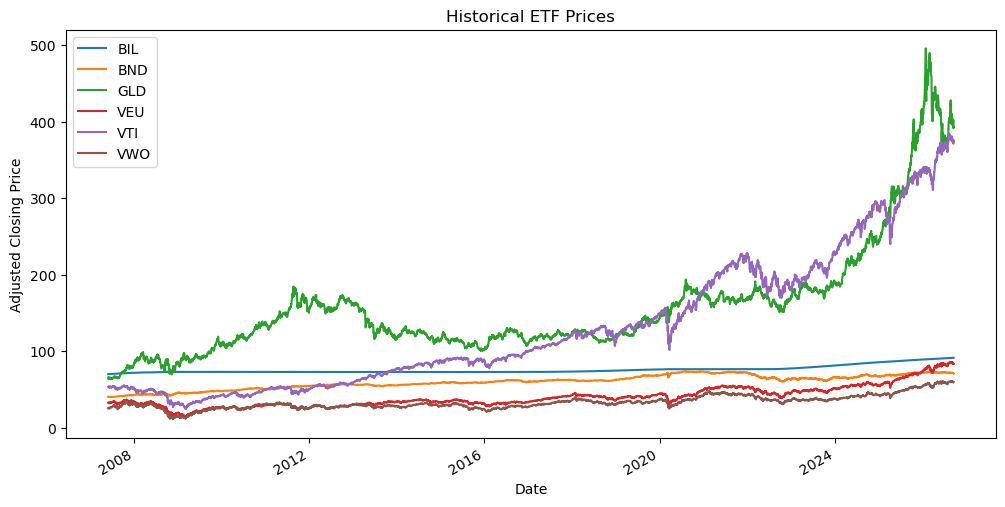

In [8]:
#Plot price history 
prices.plot(figsize=(12,6))
plt.title("Historical ETF Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.show()

In [9]:
#Calculate daily returns

returns = prices.pct_change().dropna()
returns.to_csv("returns_daily.csv")

## Key Takeaways

The final dataset provides a continuous historical series for all six portfolio asset classes using VEU and BIL as proxies where the intended implementation ETFs lack sufficient history. Observations prior to the availability of all required ETFs are excluded rather than estimated.

The cleaned daily price data are converted to returns and saved for use in the portfolio construction and risk-analysis notebooks that follow.
